### imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

df = pd.read_pickle('ChessGames.pkl')
df_moves = pd.read_pickle('ChessGamesWithMoves.pkl')

df['Opening'] = df['Opening'].str.split(':').str[0].str.strip()
df_moves['Opening'] = df_moves['Opening'].str.split(':').str[0].str.strip()
df['TimeControl'] = df['TimeControl'].str.split('+').str[0]



### train/test and cross validation split

In [ ]:
X = df[['WhiteElo', 'BlackElo', 'Event', 'TimeControl', 'Opening']]
y = df['Result'] 

numeric_features = ['WhiteElo', 'BlackElo']
categorical_features = ['Event', 'TimeControl', 'Opening']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         categorical_features)
    ]
)

model = Pipeline([
    ('preprocess', preprocessor),
    ('clf', HistGradientBoostingClassifier(
        categorical_features=[len(numeric_features) + i for i in range(len(categorical_features))],
        random_state=42
    ))
])

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=323, shuffle=True, stratify=y
)

print(f"Train/val size: {len(X_train_val)}, Test size: {len(X_test)}")

kf = KFold(n_splits=10, shuffle=True, random_state=31)
for col in ['Event', 'TimeControl', 'Opening']:
    print(col, df[col].nunique())
scores = cross_val_score(model, X_train_val, y_train_val, cv=kf, scoring='accuracy')

print(f"CV accuracy per fold: {scores}")
print(f"Mean CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

model.fit(X_train_val, y_train_val)
test_acc = model.score(X_test, y_test)
print(f"Final test accuracy: {test_acc:.4f}")

print(y_train_val.value_counts(normalize=True))


Train/val size: 81703, Test size: 9079
Event 4
TimeControl 35
Opening 135
CV accuracy per fold: [0.51878595 0.53077959 0.51952025 0.52301102 0.50991432 0.51517748
 0.5244798  0.52019584 0.52166463 0.51762546]
Mean CV accuracy: 0.5201 ± 0.0053
Final test accuracy: 0.5181
Result
1-0        0.499725
0-1        0.465956
1/2-1/2    0.034319
Name: proportion, dtype: float64


### Elo comparison with Classifier predictions

In [59]:
def elo_expected_score(white_elo, black_elo):
    return 1 / (1 + 10 ** ((black_elo - white_elo) / 400))

def elo_to_class(white_elo, black_elo, draw_margin=0.0005):
    exp_score = elo_expected_score(white_elo, black_elo)
    if exp_score > 0.5 + draw_margin:
        return '1-0'
    elif exp_score < 0.5 - draw_margin:
        return '0-1'
    else:
        return '1/2-1/2'

elo_preds = X_test.apply(lambda row: elo_to_class(row['WhiteElo'], row['BlackElo']), axis=1)

elo_acc = (elo_preds.reset_index(drop=True) == y_test.reset_index(drop=True)).mean()
print(f"Elo-formula baseline accuracy: {elo_acc:.4f}")

Elo-formula baseline accuracy: 0.5085


In [72]:
df_moves['GameID'] = (
    df_moves['Event'].astype(str) + '_' +
    df_moves['White'].astype(str) + '_' +
    df_moves['Black'].astype(str) + '_'
)

X_mov = df_moves.drop(columns=['Target_Is_Blunder'])
y_mov = df_moves['Target_Is_Blunder']
groups = df_moves['GameID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=323)
train_val_idx, test_idx = next(gss.split(X_mov, y_mov, groups=groups))

X_train_val_mov, X_test_mov = X_mov.iloc[train_val_idx], X_mov.iloc[test_idx]
y_train_val_mov, y_test_mov = y_mov.iloc[train_val_idx], y_mov.iloc[test_idx]
groups_train_val_mov = groups.iloc[train_val_idx]

print(f"Train/val rows: {len(X_train_val_mov)}, games: {groups_train_val_mov.nunique()}")
print(f"Test rows: {len(X_test_mov)}, games: {groups.iloc[test_idx].nunique()}")

# sanity check: no game appears in both sets
assert set(groups_train_val_mov) & set(groups.iloc[test_idx]) == set()
print("No leakage between train/val and test sets.")

Train/val rows: 292513, games: 4496
Test rows: 33071, games: 500
No leakage between train/val and test sets.


### train/test split by groups to prevent data leakage

In [ ]:
leak_cols = ['Eval_After', 'Eval_Drop', 'GameID', 'White', 'Black', 'Result', 'ECO']
feature_cols = [c for c in X_train_val_mov.columns if c not in leak_cols]

numeric_features = ['WhiteElo', 'BlackElo', 'GameLength', 'Is_White_Turn',
                     'Move_Number', 'Clock_Seconds', 'Eval_Before']
categorical_features = ['Event', 'Opening', 'Termination', 'TimeControl']

numeric_features = [c for c in numeric_features if c in feature_cols]
categorical_features = [c for c in categorical_features if c in feature_cols]

X_train_val_feat = X_train_val_mov[numeric_features + categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         categorical_features)
    ]
)

model_mov = Pipeline([
    ('preprocess', preprocessor),
    ('clf', HistGradientBoostingClassifier(
        categorical_features=[len(numeric_features) + i for i in range(len(categorical_features))],
        class_weight='balanced',  # blunders are almost certainly a minority class
        random_state=42
    ))
])

gkf = GroupKFold(n_splits=10)

scores = cross_val_score(
    model_mov, X_train_val_feat, y_train_val_mov,
    cv=gkf, groups=groups_train_val_mov,
    scoring='roc_auc'
)

print(f"CV ROC-AUC per fold: {scores}")
print(f"Mean CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

CV ROC-AUC per fold: [0.7421692  0.75060854 0.75592806 0.74593375 0.73924623 0.75303467
 0.7468106  0.74301801 0.7498062  0.7339163 ]
Mean CV ROC-AUC: 0.7460 ± 0.0063


### some feature importance beyond Elo

In [ ]:
model_mov.fit(X_train_val_feat, y_train_val_mov)

result = permutation_importance(
    model_mov, X_train_val_feat, y_train_val_mov,
    n_repeats=5, random_state=42, scoring='roc_auc'
)
for i in result.importances_mean.argsort()[::-1]:
    print(f"{X_train_val_feat.columns[i]}: {result.importances_mean[i]:.4f} ± {result.importances_std[i]:.4f}")

Move_Number: 0.1700 ± 0.0026
Eval_Before: 0.0982 ± 0.0013
GameLength: 0.0505 ± 0.0002
Opening: 0.0435 ± 0.0002
Is_White_Turn: 0.0401 ± 0.0006
Clock_Seconds: 0.0194 ± 0.0005
BlackElo: 0.0181 ± 0.0005
TimeControl: 0.0162 ± 0.0003
WhiteElo: 0.0122 ± 0.0004
Termination: 0.0031 ± 0.0001
Event: 0.0000 ± 0.0000


In [77]:
df['EloDiff'] = df['WhiteElo'] - df['BlackElo']

In [78]:
thresholds = [0, 50, 100, 150, 200, 300, 400, 500]
acc_by_threshold = []

for t in thresholds:
    subset = df[df['EloDiff'].abs() >= t]
    if len(subset) < 50:
        continue
    preds = subset.apply(
        lambda row: elo_to_class(row['WhiteElo'], row['BlackElo'], draw_margin=0.0), axis=1
    )
    acc = (preds.reset_index(drop=True) == subset['Result'].reset_index(drop=True)).mean()
    acc_by_threshold.append((t, acc, len(subset)))

for t, acc, n in acc_by_threshold:
    print(f"threshold={t}: accuracy={acc:.4f}, n_games={n}")

threshold=0: accuracy=0.5082, n_games=90782
threshold=50: accuracy=0.5455, n_games=33144
threshold=100: accuracy=0.5786, n_games=12367
threshold=150: accuracy=0.5947, n_games=4209
threshold=200: accuracy=0.5652, n_games=2263
threshold=300: accuracy=0.5887, n_games=1201
threshold=400: accuracy=0.6272, n_games=684
threshold=500: accuracy=0.6675, n_games=403


In [80]:
game_key = ['Event', 'White', 'Black', 'WhiteElo', 'BlackElo']

side_blunders = (
    df_moves.groupby(game_key + ['Is_White_Turn'])['Target_Is_Blunder']
    .sum()
    .unstack(fill_value=0)
    .rename(columns={1: 'WhiteBlunders', 0: 'BlackBlunders'})
    .reset_index()
)

game_result = df[game_key + ['Result']].drop_duplicates()
merged = side_blunders.merge(game_result, on=game_key, how='inner')

merged['EloDiff'] = merged['WhiteElo'] - merged['BlackElo']
merged['Favorite'] = np.where(merged['EloDiff'] > 0, 'White', 'Black')
merged['FavoriteWon'] = np.where(
    ((merged['Favorite'] == 'White') & (merged['Result'] == '1-0')) |
    ((merged['Favorite'] == 'Black') & (merged['Result'] == '0-1')),
    True, False
)
merged['IsDraw'] = merged['Result'] == '1/2-1/2'
merged['IsUpset'] = (~merged['FavoriteWon']) & (~merged['IsDraw'])
merged = merged[merged['EloDiff'].abs() >= 100].copy()

merged['FavoriteBlunders'] = np.where(
    merged['Favorite'] == 'White', merged['WhiteBlunders'], merged['BlackBlunders']
)
merged['UnderdogBlunders'] = np.where(
    merged['Favorite'] == 'White', merged['BlackBlunders'], merged['WhiteBlunders']
)

merged['BlunderDiff'] = merged['FavoriteBlunders'] - merged['UnderdogBlunders']
merged['BlunderDiffBucket'] = pd.cut(
    merged['BlunderDiff'], bins=[-100, -3, -1, 0, 1, 3, 100],
    labels=['Fav far cleaner', 'Fav cleaner', 'Even/Fav+1', 'Even/Dog+1', 'Dog cleaner', 'Dog far cleaner']
)

upset_by_diff = (
    merged[~merged['IsDraw']]
    .groupby('BlunderDiffBucket', observed=True)['IsUpset']
    .agg(UpsetRate='mean', NumGames='size')
    .reset_index()
)

/var/folders/xp/s0b521gj02x0sbpkff5j333m0000gn/T/ipykernel_10689/141714393.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x='Method', y='Accuracy', palette='Blues_d')


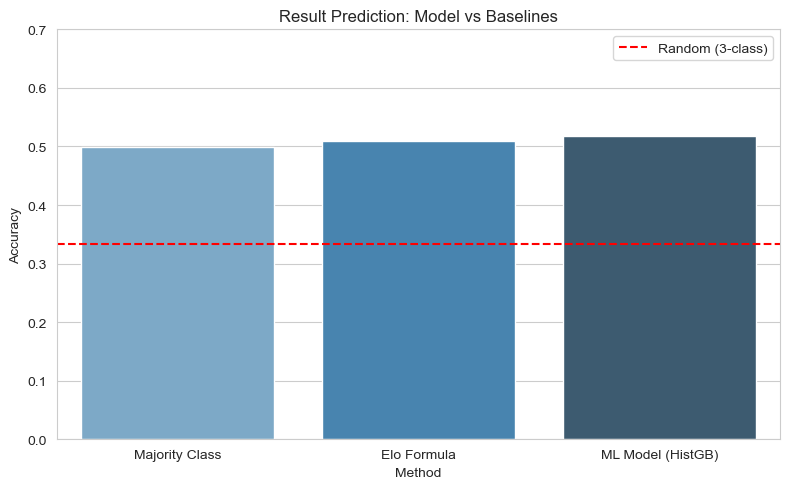

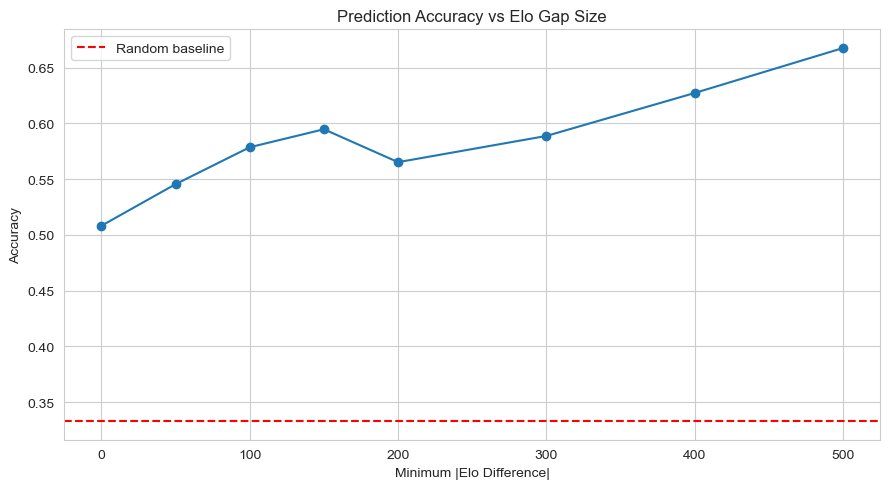

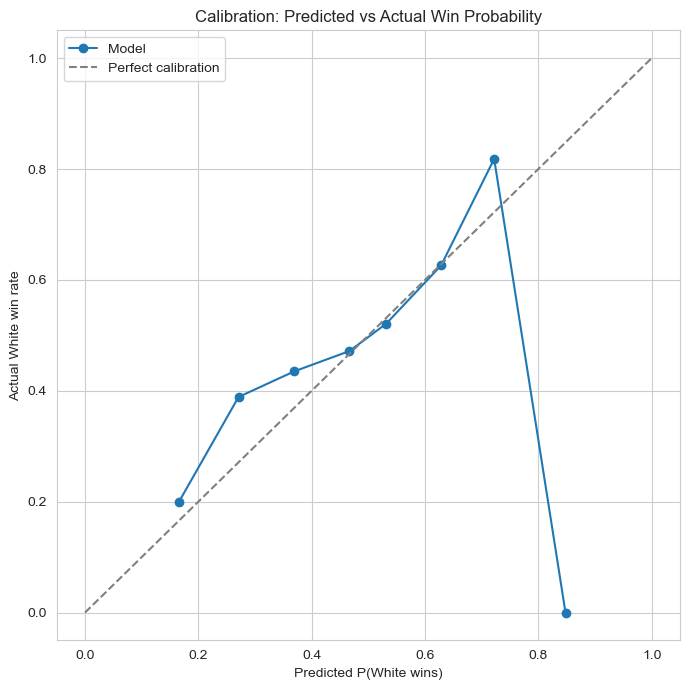

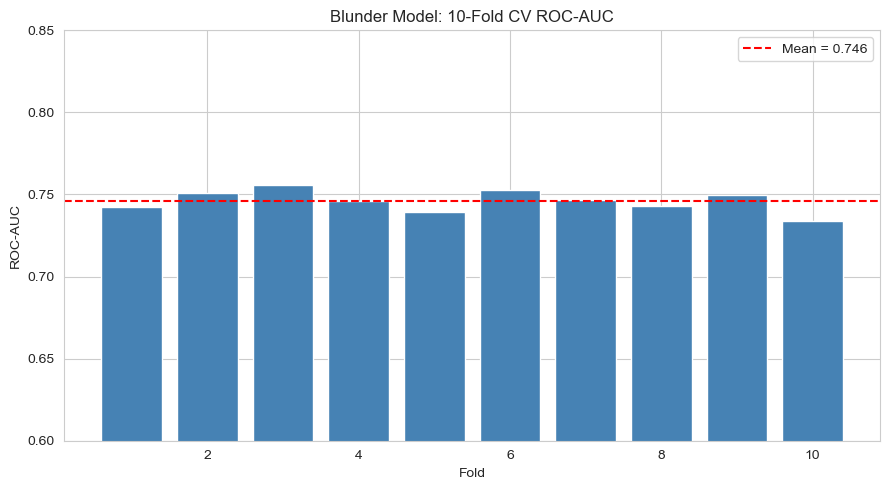

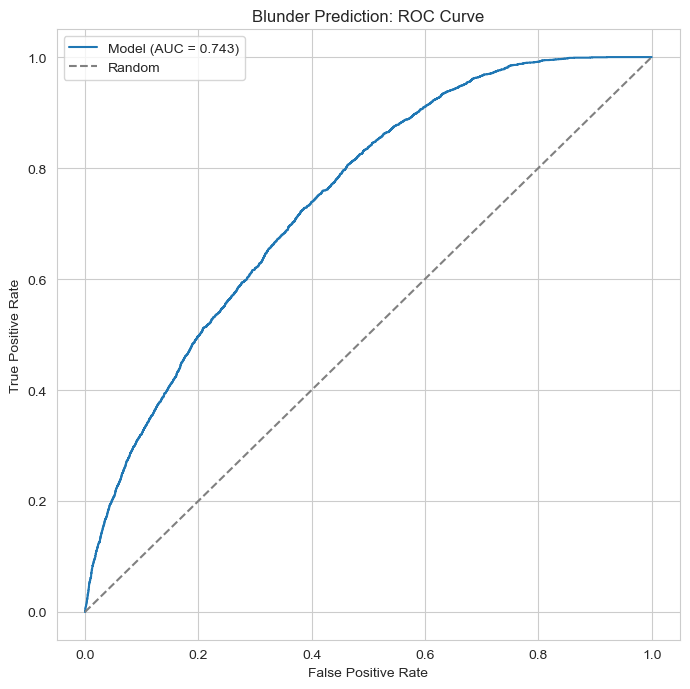

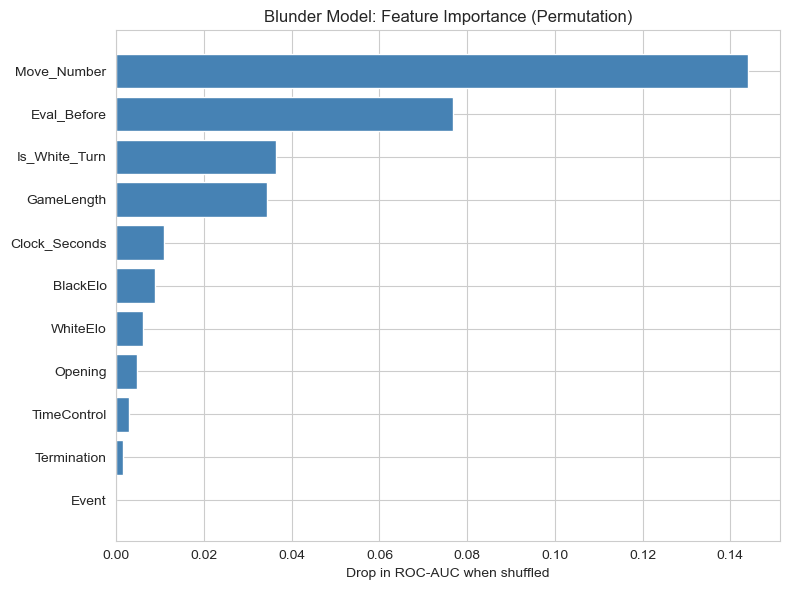

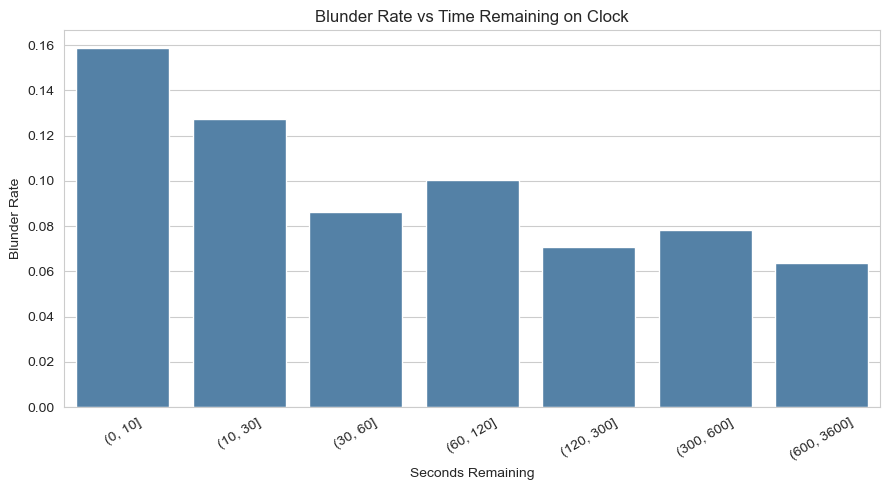

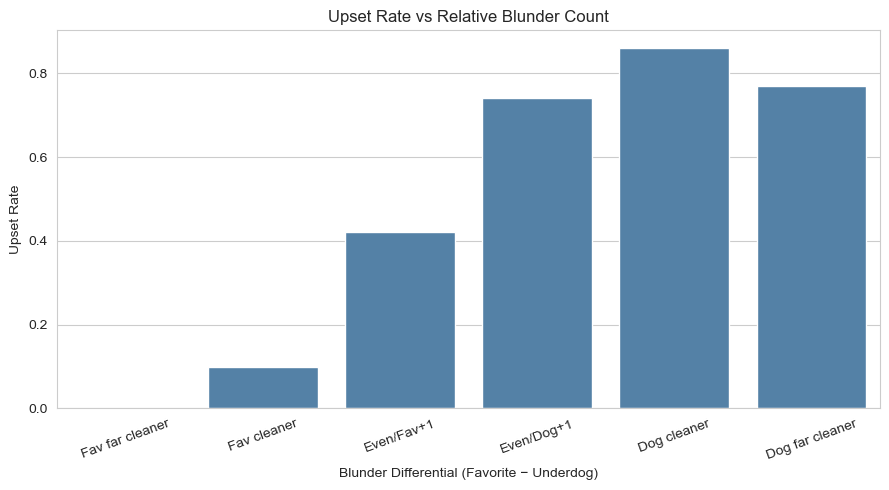

In [ ]:
sns.set_style("whitegrid")


majority_baseline = y_train_val.value_counts(normalize=True).max()

comparison = pd.DataFrame({
    'Method': ['Majority Class', 'Elo Formula', 'ML Model (HistGB)'],
    'Accuracy': [majority_baseline, elo_acc, test_acc]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x='Method', y='Accuracy', palette='Blues_d')
plt.axhline(0.333, color='red', linestyle='--', label='Random (3-class)')
plt.title('Result Prediction: Model vs Baselines')
plt.ylabel('Accuracy')
plt.ylim(0, 0.7)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
thresholds_plot, acc_plot, _ = zip(*acc_by_threshold)
plt.plot(thresholds_plot, acc_plot, marker='o')
plt.axhline(0.333, color='red', linestyle='--', label='Random baseline')
plt.title('Prediction Accuracy vs Elo Gap Size')
plt.xlabel('Minimum |Elo Difference|')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

probs = model.predict_proba(X_test)[:, list(model.classes_).index('1-0')]
y_binary = (y_test == '1-0').astype(int)
prob_true, prob_pred = calibration_curve(y_binary, probs, n_bins=10)

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Predicted P(White wins)')
plt.ylabel('Actual White win rate')
plt.title('Calibration: Predicted vs Actual Win Probability')
plt.legend()
plt.tight_layout()
plt.show()

fold_scores = [0.7421692, 0.75060854, 0.75592806, 0.74593375, 0.73924623,
               0.75303467, 0.7468106, 0.74301801, 0.7498062, 0.7339163]

plt.figure(figsize=(9, 5))
plt.bar(range(1, 11), fold_scores, color='steelblue')
plt.axhline(np.mean(fold_scores), color='red', linestyle='--',
            label=f'Mean = {np.mean(fold_scores):.3f}')
plt.title('Blunder Model: 10-Fold CV ROC-AUC')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.ylim(0.6, 0.85)
plt.legend()
plt.tight_layout()
plt.show()

# 2b. ROC curve on held-out test set
model_mov.fit(X_train_val_feat, y_train_val_mov)
X_test_feat = X_test_mov[numeric_features + categorical_features]
y_score = model_mov.predict_proba(X_test_feat)[:, 1]

fpr, tpr, _ = roc_curve(y_test_mov, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, label=f'Model (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Blunder Prediction: ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

result = permutation_importance(
    model_mov, X_test_feat, y_test_mov, n_repeats=5, random_state=42, scoring='roc_auc'
)
importances = pd.DataFrame({
    'Feature': X_test_feat.columns,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importances['Feature'], importances['Importance'], color='steelblue')
plt.title('Blunder Model: Feature Importance (Permutation)')
plt.xlabel('Drop in ROC-AUC when shuffled')
plt.tight_layout()
plt.show()

df_moves['ClockBucket'] = pd.cut(df_moves['Clock_Seconds'], bins=[0,10,30,60,120,300,600,3600])
blunder_by_clock = df_moves.groupby('ClockBucket', observed=True)['Target_Is_Blunder'].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=blunder_by_clock, x='ClockBucket', y='Target_Is_Blunder', color='steelblue')
plt.title('Blunder Rate vs Time Remaining on Clock')
plt.xlabel('Seconds Remaining')
plt.ylabel('Blunder Rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=upset_by_diff, x='BlunderDiffBucket', y='UpsetRate', color='steelblue')
plt.title('Upset Rate vs Relative Blunder Count')
plt.xlabel('Blunder Differential (Favorite − Underdog)')
plt.ylabel('Upset Rate')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()